# Import Required libraries

In [ ]:
# Import basic packages
import os
import warnings
warnings.filterwarnings("ignore")
import datetime
from IPython.display import display, Markdown

# Basic ds packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# decorator packages
from typing import List, Dict
import warnings
warnings.filterwarnings("ignore")

#sklearn packages
from sklearn.base import BaseEstimator, TransformerMixin

# Tensorflow packages
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.layers import (Dense,
                                    Layer,
                                    BatchNormalization)
from tensorflow.keras.callbacks import (EarlyStopping, 
                                        ModelCheckpoint)
from tensorflow.keras.optimizers import (Adam, 
                                         AdamW, 
                                         RMSprop)
from tensorflow.keras.losses import (SparseCategoricalCrossentropy,
                                     CategoricalCrossentropy)


# Tensorflow Text Packages
import nltk
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud, STOPWORDS
from tensorflow.keras.preprocessing.text import Tokenizer


# Load Amazon Reviews Dataset

In [7]:
amazon_review_data = pd.read_csv("/Users/kavisanthoshkumar/Downloads/train.csv", header = None)
amazon_review_data.columns = ["polarity", "title", "text"]
amazon_review_data.head()

,polarity,title,text
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the ...
1,2,The best soundtrack ever to anything.,I'm reading a lot of reviews saying that this ...
2,2,Amazing!,This soundtrack is my favorite music of all ti...
3,2,Excellent Soundtrack,I truly like this soundtrack and I enjoy video...
4,2,"Remember, Pull Your Jaw Off The Floor After He...","If you've played the game, you know how divine..."


In [8]:
print(f"Number of Reviews : {amazon_review_data.shape[0]}")
# We have 3.6M reviews

Number of Reviews : 3600000


#### 1. WordCloud Visualization



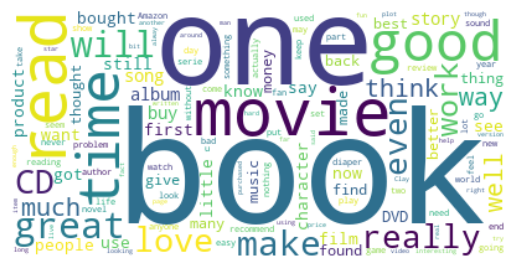

In [11]:
sentence_corpus = amazon_review_data["text"].to_list()
text = " ".join(sent for sent in sentence_corpus[:20000])

# eliminating stopwords while visualizing 
stopwords = set(STOPWORDS)

# Generating wordcloud image 
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)

# Displaying the generated image
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

#### 3. Preprocessing 


- Involves cleaning the text data by removing special characters, converting to lowercase, converting to base form, and removing stop words.

In [84]:
def tokenize_fn(text):

    # converting into lowercase
    text = tf.strings.lower(text)

    # white space tokenization
    white_space_tokens = tf.expand_dims(tf.strings.split(text, sep = " "), axis = 0)

    # remove stopwords from the text
    tf_stop_words = tf.expand_dims(tf.constant(list(STOPWORDS)), axis=0)

    # While performing set difference make sure there dimensions of shape[0] is same 
    tokens = tf.sets.difference(white_space_tokens, tf_stop_words)

    return tokens.values

# Convert sentence_corpus into tensorflow datasets
tf_sentence_corpus = tf.constant(sentence_corpus)
tf_sentence_corpus = tf.data.Dataset.from_tensor_slices(tf_sentence_corpus)
tf_sentence_corpus = tf_sentence_corpus.map(tokenize_fn, num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
for i in tf_sentence_corpus.take(2):
    print("*"*200)
    print(i)

********************************************************************************************************************************************************************************************************
tf.Tensor(
[b'^_^' b'a' b'all' b'anyone' b'away' b'backs' b'beautiful!' b'best'
 b'but' b'cares' b'chrono' b'cross' b'crude' b'even' b'ever' b'fresher'
 b'from' b'game' b'games' b'grate' b'guitars' b'has' b'hate' b'have' b'i'
 b'impress' b'it' b'keyboarding' b'listen!' b'mind' b'music!' b'of'
 b'orchestras.' b'out' b'paints' b'people' b'played' b'recomend' b'senery'
 b'so' b'soulful' b'sound' b'step' b'takes' b'this' b'to' b'track' b'vid.'
 b'was' b'well' b'who' b'with' b'would' b'your'], shape=(54,), dtype=string)
********************************************************************************************************************************************************************************************************
tf.Tensor(
[b"'game" b'a' b'any' b'are' b'be' b'beauty' b'been' b'best' b'bit

In [ ]:
list(tfds.as_numpy(tf_sentence_corpus))